<a href="https://colab.research.google.com/github/ashishreddypakala2005/smart-home-assistant-with-vision-and-chat-bot/blob/main/home_interior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-03-28 190654.png to Screenshot 2026-03-28 190654.png


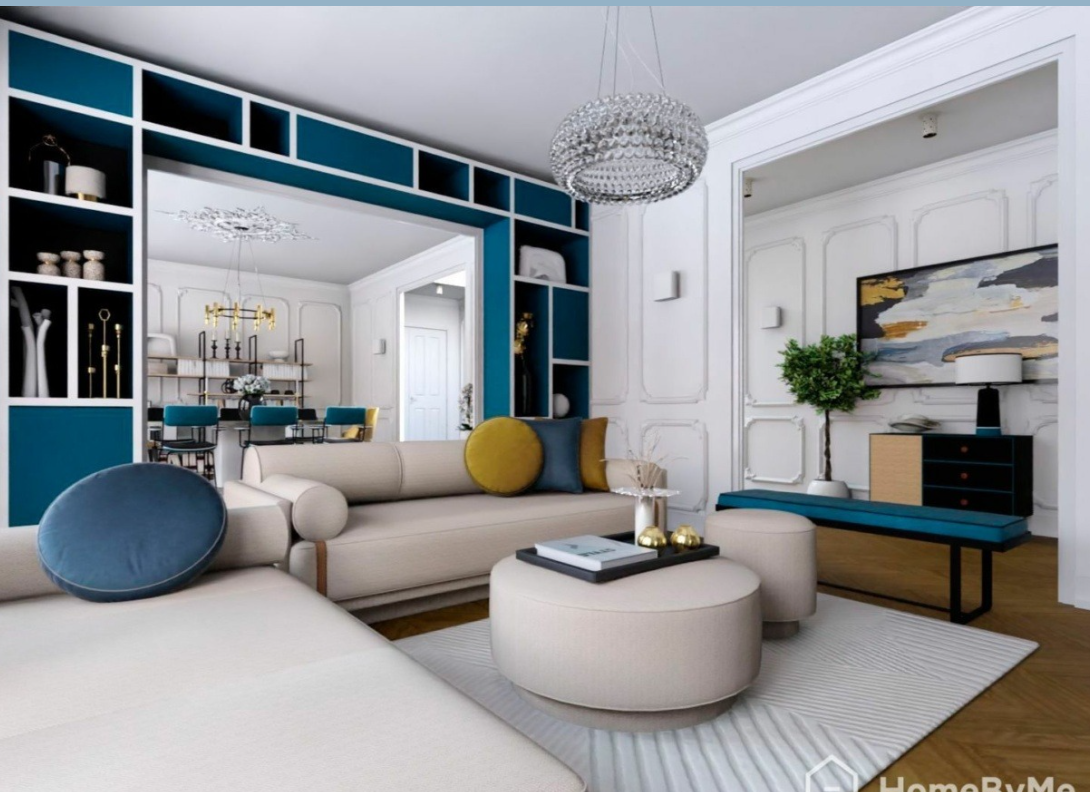

In [ ]:
from google.colab import files
uploaded = files.upload()

import os
filename = list(uploaded.keys())[0]

import cv2
img = cv2.imread(filename)

from google.colab.patches import cv2_imshow
cv2_imshow(img)

In [ ]:
!wget https://pjreddie.com/media/files/yolov3.weights

!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg

!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

--2026-03-28 13:38:12--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3030::ac43:b9c7, ...
Connecting to pjreddie.com (pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://data.pjreddie.com/files/yolov3.weights [following]
--2026-03-28 13:38:13--  https://data.pjreddie.com/files/yolov3.weights
Resolving data.pjreddie.com (data.pjreddie.com)... 104.21.88.156, 172.67.185.199, 2606:4700:3037::6815:589c, ...
Connecting to data.pjreddie.com (data.pjreddie.com)|104.21.88.156|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M   117MB/s    in 2.0s    

2026-03-28 13:38:15 (117 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]

--2026-03-28 13:38:15--  https://raw.githubusercontent.com/p

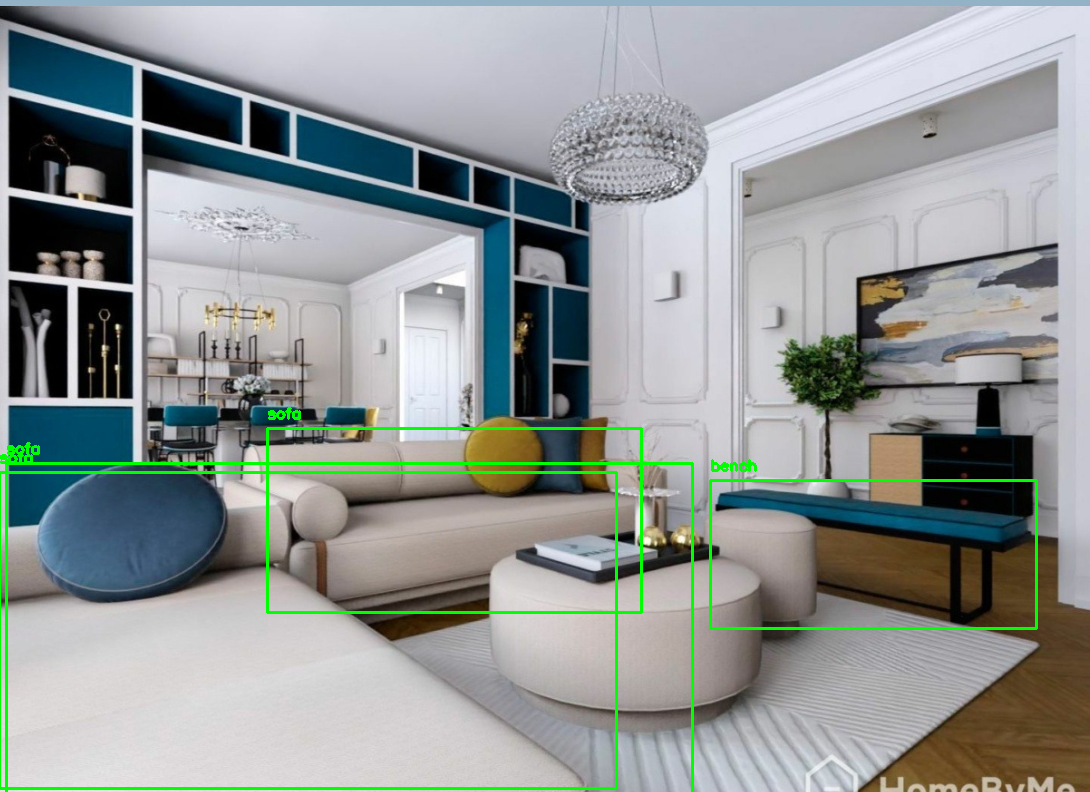

Detected objects: ['bench', 'sofa']


In [ ]:
import numpy as np



# Load YOLO model

net = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")



# Load class names (COCO dataset)

with open("coco.names", "r") as f:

    classes = [line.strip() for line in f.readlines()]



height, width, _ = img.shape



# Convert image

blob = cv2.dnn.blobFromImage(img, 1/255.0, (416,416), swapRB=True, crop=False)

net.setInput(blob)



# Get output layers

layer_names = net.getLayerNames()

output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]



outputs = net.forward(output_layers)



labels_detected = []

boxes = []



# Detection loop

for output in outputs:

    for detection in output:

        scores = detection[5:]

        class_id = np.argmax(scores)

        confidence = scores[class_id]



        if confidence > 0.5:

            label = classes[class_id]

            labels_detected.append(label)



            center_x = int(detection[0] * width)

            center_y = int(detection[1] * height)

            w = int(detection[2] * width)

            h = int(detection[3] * height)



            x = int(center_x - w / 2)

            y = int(center_y - h / 2)



            boxes.append([x, y, w, h])



# Draw boxes

for i, box in enumerate(boxes):

    x, y, w, h = box

    cv2.rectangle(img, (x,y), (x+w,y+h), (0,255,0), 2)

    cv2.putText(img, labels_detected[i], (x,y-10),

                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)



# Show result

cv2_imshow(img)



unique_objects = list(set(labels_detected))



print("Detected objects:", unique_objects)

In [ ]:
print("\nSmart Home Assistant Ready!")



while True:

    user_input = input("\nAsk something (type 'exit' to stop): ").lower()



    if user_input == "exit":

        print("Goodbye!")

        break



    # General description

    elif "what" in user_input or "see" in user_input or "picture" in user_input:

        if len(unique_objects) == 0:

            print("I cannot recognize the objects clearly.")

        else:

            print("I can see:", ", ".join(unique_objects))



    # Check specific object

    elif "is there" in user_input:

        found = False

        for obj in unique_objects:

            if obj in user_input:

                print("Yes, I can see", obj)

                found = True

                break

        if not found:

            print("No, that object is not present.")



    # Count objects

    elif "how many" in user_input:

        print("I detected", len(unique_objects), "different types of objects.")



    # Greeting

    elif "hello" in user_input:

        print("Hello! I am your smart home assistant.")



    else:

        if len(unique_objects) > 0:

            print("Detected objects are:", ", ".join(unique_objects))

        else:

            print("I could not detect any objects.")


Smart Home Assistant Ready!

Ask something (type 'exit' to stop): hii
Detected objects are: bench, sofa

Ask something (type 'exit' to stop): which objects are there
Detected objects are: bench, sofa

Ask something (type 'exit' to stop): how many objects are there
I detected 2 different types of objects.
